In [3]:
import pandas as pd
from pm_pd_utils import analyze_column, initial_dataframe_analysis
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
sns.set_theme(style='darkgrid')
custom_palette = ['#007B92', '#62CFC9', '#DC1F33', '#EFAC1E']
sns.set_palette(custom_palette)

In [5]:
PATH = 'data/ContingencyData.csv'
df_contingency = pd.read_csv(PATH, parse_dates=['timestamp'])

In [6]:
# Process df_contingency
df_contingency = df_contingency.sort_values(by=['truck_id', 'timestamp'])

In [8]:
print(f'Total rows: {df_contingency.shape[0]}')
display(analyze_column(df_contingency, 'status_name').to_frame())
display(analyze_column(df_contingency, 'status_id').to_frame())

Total rows: 75300


,status_name
status_name,
Demora,37790
Efectivo,34906
Mantencion,1359
Reserva,1245


,status_id
status_id,
226,37790
224,34906
223,1359
225,1245


### What can be done here
- Join/Concat the table with the dispatch Event Log (then the fields should match)
- This df itself can be an Event Log
- Maybe augment this data with the timestamp_end = timestamp + duration and then pivot long
```python
df_contingency_augmented = df_contingency.copy()
df_contingency_augmented['timestamp_end'] = df_contingency['timestamp'] + pd.to_timedelta(df_contingency['duration'], unit='s')
```

In [9]:
df_contingency[df_contingency['status_name'] == 'Efectivo']

,id,fieldid,shiftid,timestamp,duration,truck_id,stop_code,stop_reason,status_id,status_name
70593,2402270020010506904,03:34:55,240227002,2024-02-27 12:34:55,1584,CA100,100,Efectivo,224,Efectivo
70590,2402270020011456148,04:04:09,240227002,2024-02-27 13:04:09,567,CA100,100,Efectivo,224,Efectivo
71207,2402270020013386532,04:34:17,240227002,2024-02-27 13:34:17,507,CA100,100,Efectivo,224,Efectivo
71206,2402270020013920232,04:48:46,240227002,2024-02-27 13:48:46,87,CA100,100,Efectivo,224,Efectivo
71208,2402270020014622260,05:00:33,240227002,2024-02-27 14:00:33,2521,CA100,100,Efectivo,224,Efectivo
...,...,...,...,...,...,...,...,...,...,...
68112,2403260010010358784,03:42:07,240326001,2024-03-26 00:42:07,1008,CA99,100,Efectivo,224,Efectivo
68106,2403260010011098000,04:02:20,240326001,2024-03-26 01:02:20,9550,CA99,100,Efectivo,224,Efectivo
68103,2403260010018232716,06:46:41,240326001,2024-03-26 03:46:41,1513,CA99,100,Efectivo,224,Efectivo
68105,2403260010021413184,07:51:10,240326001,2024-03-26 04:51:10,4843,CA99,100,Efectivo,224,Efectivo


In [10]:
df = df_contingency.copy()
df = df.rename(columns={'truck_id': 'case_id'}).drop(columns=['id', 'fieldid'])
# Correct the datetime for utc change in march UTC+3
df['timestamp'] = df['timestamp'] + pd.to_timedelta(3, unit='hours')
df.head()

,shiftid,timestamp,duration,case_id,stop_code,stop_reason,status_id,status_name
70594,240227002,2024-02-27 15:30:40,255,CA100,207,Pista obstruida,226,Demora
70593,240227002,2024-02-27 15:34:55,1584,CA100,100,Efectivo,224,Efectivo
70591,240227002,2024-02-27 16:01:19,170,CA100,285,Sin equipo de carguio,226,Demora
70590,240227002,2024-02-27 16:04:09,567,CA100,100,Efectivo,224,Efectivo
70592,240227002,2024-02-27 16:13:36,1241,CA100,245,Colacion en comedor,226,Demora


In [11]:
df['timediff'] = df.groupby('case_id')['timestamp'].diff().dt.total_seconds().shift(-1)
df.sample(10) # Here timediff is absolutly the same that the duration in seconds

,shiftid,timestamp,duration,case_id,stop_code,stop_reason,status_id,status_name,timediff
42270,240310001,2024-03-10 09:31:24,654,CA57,100,Efectivo,224,Efectivo,654.0
49782,240313002,2024-03-13 15:44:51,489,CA103,100,Efectivo,224,Efectivo,489.0
60650,240323001,2024-03-23 11:08:32,1968,CA94,100,Efectivo,224,Efectivo,1968.0
38829,240309001,2024-03-09 06:20:06,850,CA107,278,Operador fuera del equipo,226,Demora,850.0
38661,240308002,2024-03-08 23:29:26,74,CA82,207,Pista obstruida,226,Demora,74.0
61824,240323002,2024-03-23 17:44:30,63,CA102,207,Pista obstruida,226,Demora,63.0
47564,240312002,2024-03-12 17:49:03,1345,CA91,100,Efectivo,224,Efectivo,1345.0
23032,240317002,2024-03-17 20:56:28,217,CA98,285,Sin equipo de carguio,226,Demora,217.0
40269,240309002,2024-03-09 14:26:58,30,CA92,207,Pista obstruida,226,Demora,30.0
30070,240319002,2024-03-19 20:32:39,2390,CA90,100,Efectivo,224,Efectivo,2390.0


<Axes: xlabel='status_name', ylabel='activity_kind'>

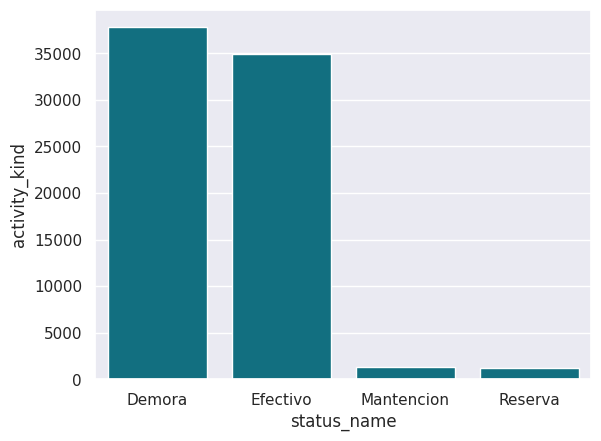

In [12]:
df_short_activity = analyze_column(df_contingency, 'status_name').to_frame().rename(columns={'status_name': 'activity_kind'}).reset_index()
sns.barplot(df_short_activity, x='status_name', y='activity_kind')

In [13]:
df[['duration', 'timediff']].dropna().sum().diff().dropna().rename(index={'timediff': 'Total difference'})

Total difference    0.0
dtype: float64

In [14]:
df_codes = df.groupby(by='stop_reason')[['stop_reason', 'timediff']].\
              agg({'stop_reason': 'count', 'timediff': 'sum'}).\
              rename(columns={'stop_reason': 'count'}).\
              reset_index().\
              sort_values(by='timediff', ascending=False)
              

In [15]:
df_codes.head()

,stop_reason,count,timediff
18,Efectivo,34903,85489285.0
30,Mecanica imprevista,517,6431019.0
29,Mantencion programada,173,4870642.0
22,Falla motor diesel,168,4150174.0
54,Sin infraestructura de apoyo,103,3268418.0


In [16]:
def replace_remaining_with_others(df: pd.DataFrame, top: int = 7) -> pd.DataFrame:
  df_replace = df.iloc[:top,:]
  others = df.iloc[top:,1:].sum(axis=0).tolist()
  return pd.concat([df_replace, pd.DataFrame(data=[['otros', *others]], columns=df.columns)])

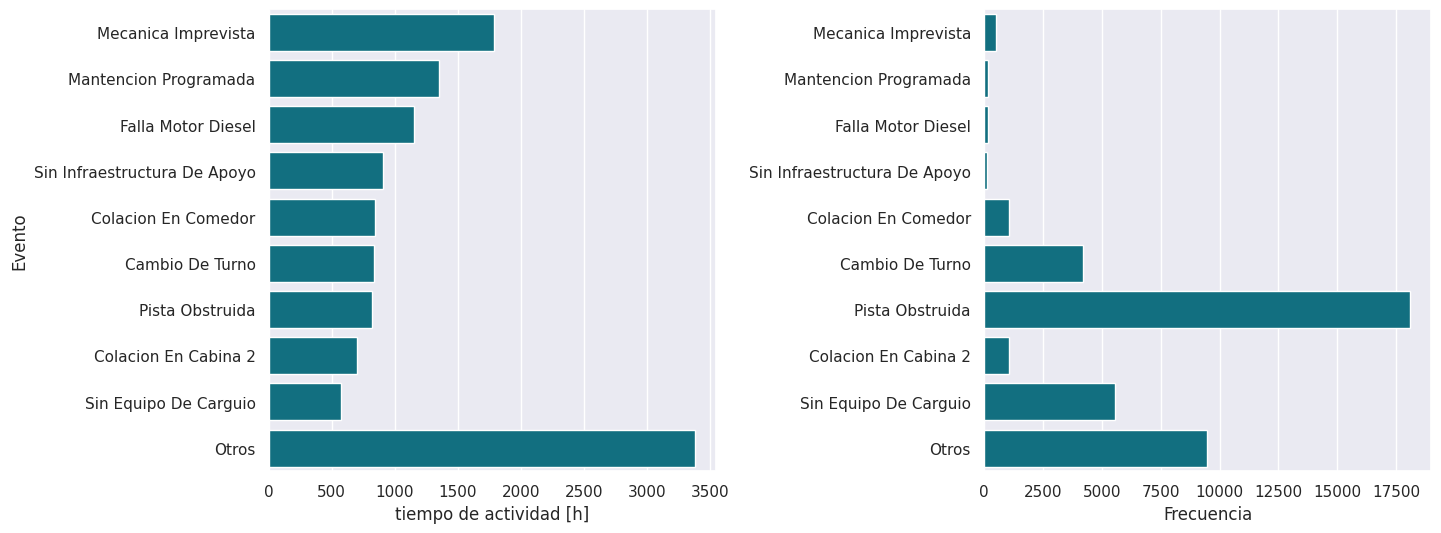

In [51]:
TOP_REASONS = 10
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(15, 6))
plt.subplots_adjust(wspace=0.6)
summary_df_event = replace_remaining_with_others(df_codes, top=TOP_REASONS).iloc[1:]
summary_df_event['timediff'] = summary_df_event['timediff'] / 3600
summary_df_event['stop_reason'] = summary_df_event['stop_reason'].str.title()
sns.barplot(summary_df_event, y='stop_reason', x='timediff', ax=ax1).set(ylabel='Evento', xlabel='tiempo de actividad [h]')
sns.barplot(summary_df_event, y='stop_reason', x='count', ax=ax2).set(ylabel=None, xlabel='Frecuencia');

In [18]:
df_log = df.copy().rename(columns={'status_name': 'activity'}).sort_values(by=['case_id', 'timestamp']).reset_index()
common_cols = ['case_id', 'activity', 'timestamp']
df_log = df_log[[*common_cols, *(set(df_log.columns) - set(common_cols))]]
df_log.head()

,case_id,activity,timestamp,stop_reason,stop_code,index,shiftid,duration,status_id,timediff
0,CA100,Demora,2024-02-27 15:30:40,Pista obstruida,207,70594,240227002,255,226,255.0
1,CA100,Efectivo,2024-02-27 15:34:55,Efectivo,100,70593,240227002,1584,224,1584.0
2,CA100,Demora,2024-02-27 16:01:19,Sin equipo de carguio,285,70591,240227002,170,226,170.0
3,CA100,Efectivo,2024-02-27 16:04:09,Efectivo,100,70590,240227002,567,224,567.0
4,CA100,Demora,2024-02-27 16:13:36,Colacion en comedor,245,70592,240227002,1241,226,1241.0


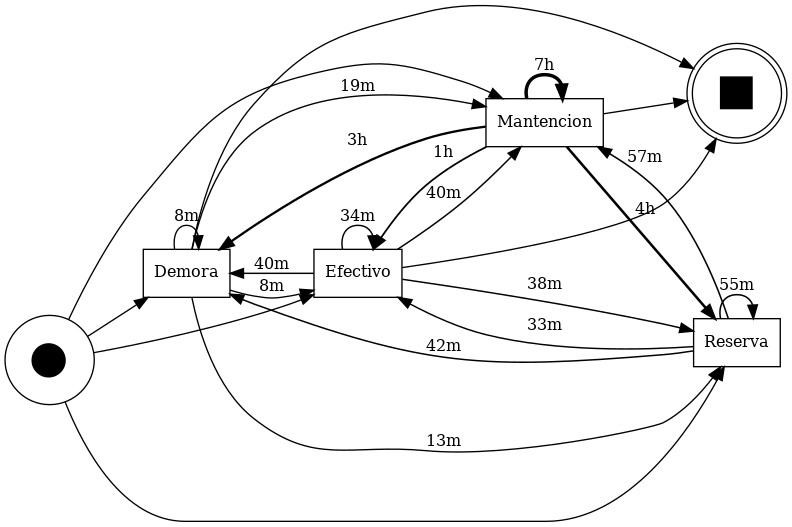

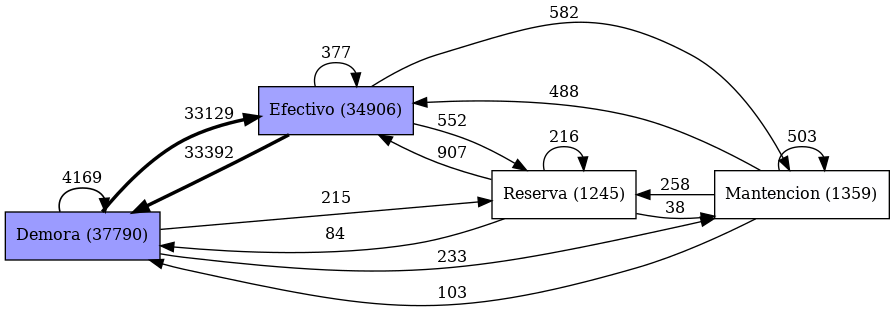

In [19]:
event_log, performance_dfg, frequency_dfg = initial_dataframe_analysis(df_log, with_dfg=True)

In [20]:
common_cols = ['start_activity', 'end_activity', 'median', 'min', 'max', 'stdev', 'sum', 'mean']
data_performance_dfg = [[*item[0], *item[1].values()] for item in dict(performance_dfg).items()]
df_performance = pd.DataFrame(data_performance_dfg, columns=common_cols)

In [21]:
df_frequency = pd.DataFrame([[*item[0], item[1]] for item in dict(frequency_dfg).items()], columns=['start_activity', 'end_activity', 'count'])
df_frequency

,start_activity,end_activity,count
0,Demora,Efectivo,33129
1,Efectivo,Demora,33392
2,Demora,Demora,4169
3,Efectivo,Mantencion,582
4,Mantencion,Efectivo,488
5,Efectivo,Efectivo,377
6,Efectivo,Reserva,552
7,Reserva,Efectivo,907
8,Reserva,Demora,84
9,Demora,Mantencion,233


In [52]:
FROM_ACTIVITY = 'Demora'
df_performance_short = df_performance[['start_activity', 'end_activity', 'mean', 'median', 'sum']]
df_performance_short.loc[:, 'sum'] = df_performance_short['sum'] / 3600
print(f'UNIQUE ACTIVITIES: {df_performance['end_activity'].unique().tolist()}')
df_performance_short[df_performance_short['end_activity'] == FROM_ACTIVITY]

UNIQUE ACTIVITIES: ['Efectivo', 'Demora', 'Mantencion', 'Reserva']


,start_activity,end_activity,mean,median,sum
1,Efectivo,Demora,2456.167435,1594.0,22782.317500
2,Demora,Demora,509.441113,402.0,589.961111
8,Reserva,Demora,2557.000000,1463.5,59.663333
12,Mantencion,Demora,12772.388350,11733.0,365.432222


<Axes: xlabel='sum', ylabel='end_activity'>

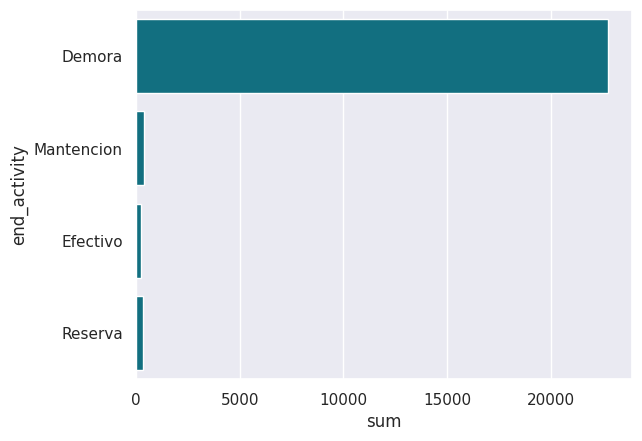

In [23]:
ACTIVITY = 'Efectivo' # One from ['Efectivo', 'Demora', 'Mantencion', 'Reserva']
METRIC = 'sum' # One from ['mean', 'median', 'count']
df_summary = df_frequency.merge(df_performance_short, on=['start_activity', 'end_activity'])
sns.barplot(df_summary[df_summary['start_activity'] == ACTIVITY], x=METRIC, y='end_activity')

In [25]:
df_activity_reason = df_log.groupby(by=['activity', 'stop_reason'])[['activity', 'stop_reason']].\
                            count().\
                            drop(columns=['activity']).\
                            rename(columns={'stop_reason': 'count'}).\
                            reset_index()                            
df_activity_reason.sample(10)

,activity,stop_reason,count
19,Efectivo,OPERATIVO AUX,3
10,Demora,Operador fuera del equipo,2918
41,Mantencion,Reparacion equipo accidentado,17
31,Mantencion,Mant. Prog. Motor diesel,12
29,Mantencion,Inspeccion tecnica,39
49,Mantencion,Sistema dispatch - modular,2
33,Mantencion,Mantencion programada,173
26,Mantencion,Falla electrica imprevista,26
22,Mantencion,CHEQUEO NEUMATICO NO PROGRAMA,16
51,Reserva,ACTIVIDAD DE SEGURIDAD,93


Possible values: ['Demora', 'Efectivo', 'Mantencion', 'Reserva']


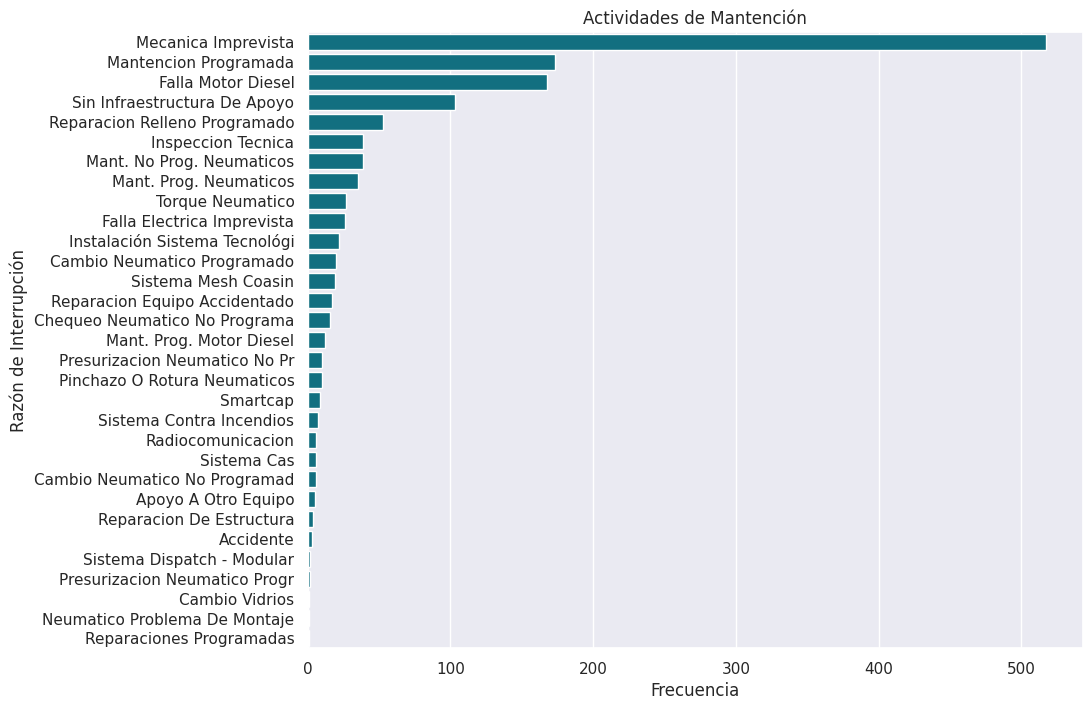

In [26]:
print(f'Possible values: {df_activity_reason['activity'].unique().tolist()}')
df_act_sort = df_activity_reason.sort_values(by=['count'], ascending=False)
df_act_sort['stop_reason'] = df_act_sort['stop_reason'].str.title()
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
ax = sns.barplot(df_act_sort[df_act_sort['activity'] == 'Mantencion'], x='count', y='stop_reason')
ax.set(title="Actividades de Mantención", ylabel="Razón de Mantención", xlabel="Frecuencia");

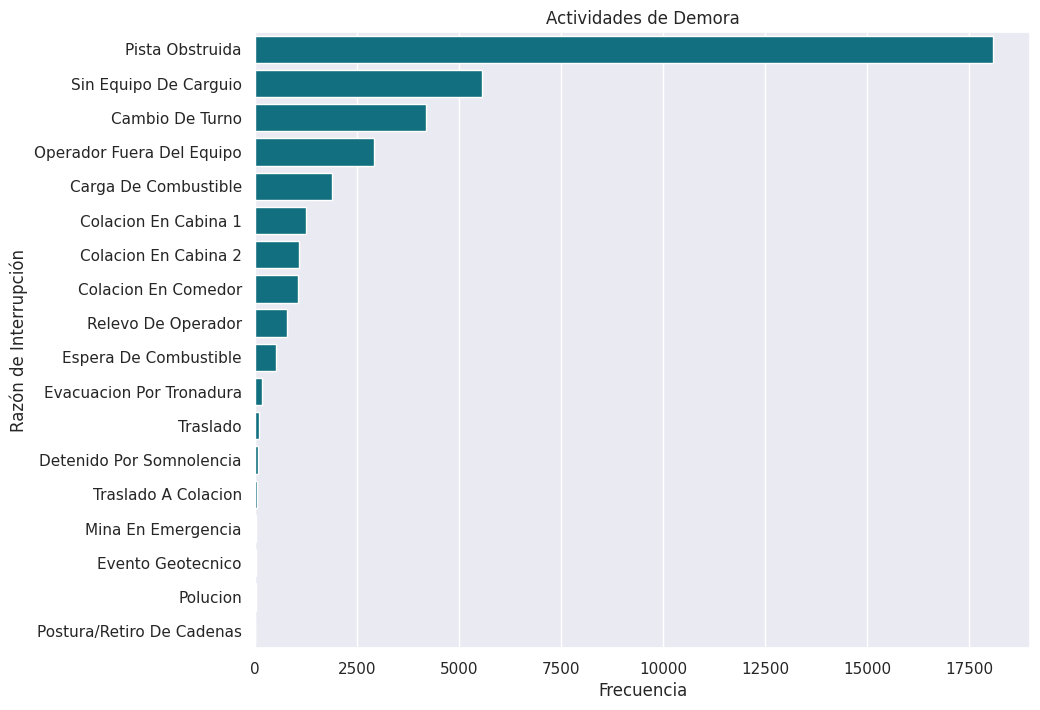

In [27]:
def group_and_plot_by_activity(df, activity, stop_reason_col='stop_reason'):
  df_act_sort = df.sort_values(by=['count'], ascending=False)
  df_act_sort['stop_reason'] = df_act_sort[stop_reason_col].str.title()
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
  ax = sns.barplot(df_act_sort[df_act_sort['activity'] == activity], x='count', y=stop_reason_col)
  ax.set(title=f"Actividades de {activity}", ylabel="Razón de Demora", xlabel="Frecuencia")
  return fig

group_and_plot_by_activity(df_activity_reason, 'Demora');

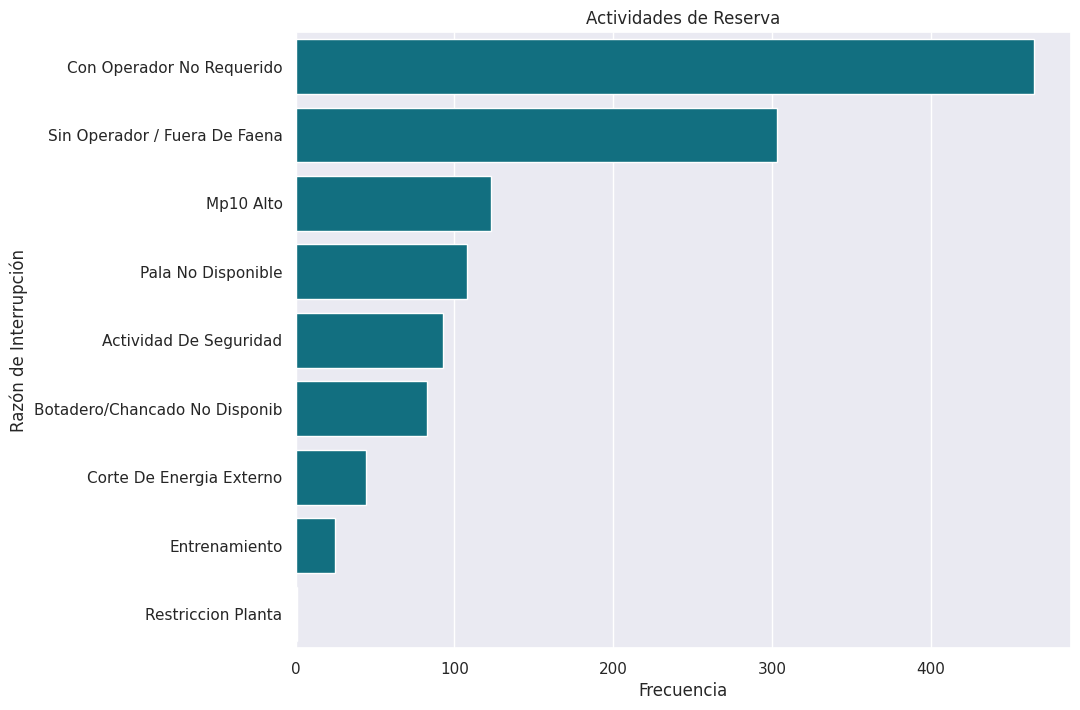

In [48]:
group_and_plot_by_activity(df_activity_reason, 'Reserva');

In [28]:
print(f'Total horas             : {df_log['timediff'].sum() / 3600:.2f}')
print(f'Total horas no efectivas: {df_log[df_log['activity'] != 'Efectivo']['timediff'].sum() / 3600:.2f}')

Total horas             : 36097.92
Total horas no efectivas: 12349.83


In [29]:
# Gather common activities
df_not_repeated_log = df_log.copy()
df_not_repeated_log['grouped_consecutives'] = (df_not_repeated_log['activity'] != df_not_repeated_log['activity'].shift()).cumsum()
df_not_repeated_log['group_sum'] = df_not_repeated_log.groupby(by='grouped_consecutives').cumcount() + 1
df_not_repeated_log.drop(columns=['grouped_consecutives']);
total_rows = df_not_repeated_log.shape[0]
df_not_repeated_log = df_not_repeated_log[df_not_repeated_log['group_sum'] == 1]
filtered_rows = df_not_repeated_log.shape[0]
print(f'Filtered a total of {total_rows - filtered_rows} rows')

Filtered a total of 5296 rows


In [30]:
df_not_repeated_log['total_duration'] = df_not_repeated_log['timestamp'].diff().dt.total_seconds().shift(-1)
df_not_repeated_log.head()

,case_id,activity,timestamp,stop_reason,stop_code,index,shiftid,duration,status_id,timediff,grouped_consecutives,group_sum,total_duration
0,CA100,Demora,2024-02-27 15:30:40,Pista obstruida,207,70594,240227002,255,226,255.0,1,1,255.0
1,CA100,Efectivo,2024-02-27 15:34:55,Efectivo,100,70593,240227002,1584,224,1584.0,2,1,1584.0
2,CA100,Demora,2024-02-27 16:01:19,Sin equipo de carguio,285,70591,240227002,170,226,170.0,3,1,170.0
3,CA100,Efectivo,2024-02-27 16:04:09,Efectivo,100,70590,240227002,567,224,567.0,4,1,567.0
4,CA100,Demora,2024-02-27 16:13:36,Colacion en comedor,245,70592,240227002,1241,226,1241.0,5,1,1241.0


In [31]:
df_not_repeated_log['timestamp_end'] = df_not_repeated_log['timestamp'] + pd.to_timedelta(df_not_repeated_log['total_duration'].fillna(0), 'seconds')

In [32]:
df_not_repeated_log.head(5)

,case_id,activity,timestamp,stop_reason,stop_code,index,shiftid,duration,status_id,timediff,grouped_consecutives,group_sum,total_duration,timestamp_end
0,CA100,Demora,2024-02-27 15:30:40,Pista obstruida,207,70594,240227002,255,226,255.0,1,1,255.0,2024-02-27 15:34:55
1,CA100,Efectivo,2024-02-27 15:34:55,Efectivo,100,70593,240227002,1584,224,1584.0,2,1,1584.0,2024-02-27 16:01:19
2,CA100,Demora,2024-02-27 16:01:19,Sin equipo de carguio,285,70591,240227002,170,226,170.0,3,1,170.0,2024-02-27 16:04:09
3,CA100,Efectivo,2024-02-27 16:04:09,Efectivo,100,70590,240227002,567,224,567.0,4,1,567.0,2024-02-27 16:13:36
4,CA100,Demora,2024-02-27 16:13:36,Colacion en comedor,245,70592,240227002,1241,226,1241.0,5,1,1241.0,2024-02-27 16:34:17


In [33]:
summary_unique_contingencies = df_log[['stop_reason', 'activity']].\
                                 drop_duplicates().\
                                 groupby(by=['stop_reason', 'activity']).\
                                 count().\
                                 reset_index().\
                                 sort_values(by=['activity', 'stop_reason'])[['activity', 'stop_reason']].\
                                 reset_index(drop=True)
summary_unique_contingencies.to_csv('data/summary_unique_contigencies.csv', index=False)

In [34]:
MAPPED_FILE_PATH = 'data/mapped_stop_reasons.csv'
df_stop_reasons_mapped = pd.read_csv(MAPPED_FILE_PATH) # columns: ['stop_reason', 'manual_parsing', 'grouped']

In [49]:
df_stop_reasons_mapped.head()

,stop_reason,manual_parsing,grouped
0,COLACION EN CABINA 1,Colacion en cabina 1,Colacion cabina
1,COLACION EN CABINA 2,Colacion en cabina 2,Colacion cabina
2,Cambio de turno,Cambio de turno,Cambio de turno
3,Carga de combustible,Carga de combustible,Carga de combustible
4,Colacion en comedor,Colacion en comedor,Colacion comedor


In [35]:
stop_reasons_map = df_stop_reasons_mapped[['stop_reason', 'grouped']].set_index('stop_reason').to_dict()['grouped']

In [36]:
# Integrity check that all cases are covered
assert len(set(df_not_repeated_log['stop_reason'].unique()).symmetric_difference(set(stop_reasons_map.keys()))) == 0

In [37]:
df_remapped = df_not_repeated_log.copy()
df_remapped['stop_reason'] = df_not_repeated_log['stop_reason'].map(stop_reasons_map)
columns_to_drop = ['grouped_consecutives', 'group_sum', 'total_duration', 'index', 'stop_code', 'status_id', 'duration']
df_remapped = df_remapped.drop(columns=columns_to_drop)
# Change the activity to stop_reason
df_remapped = df_remapped.rename(columns={'activity': 'type_activity', 'stop_reason': 'activity'})

In [38]:
minimal_cols = ['case_id', 'activity', 'timestamp']
necessary_cols = ['timestamp_end', 'timediff', 'shiftid']
df_remapped = df_remapped[[*minimal_cols, *necessary_cols]].reset_index(drop=True)

In [39]:
SAVE_CSV = False
if SAVE_CSV:
  df_remapped.to_csv('data/remapped_contingencies_log.csv', index=False)

In [45]:
df_log.head()

,case_id,activity,timestamp,stop_reason,stop_code,index,shiftid,duration,status_id,timediff
0,CA100,Demora,2024-02-27 15:30:40,Pista obstruida,207,70594,240227002,255,226,255.0
1,CA100,Efectivo,2024-02-27 15:34:55,Efectivo,100,70593,240227002,1584,224,1584.0
2,CA100,Demora,2024-02-27 16:01:19,Sin equipo de carguio,285,70591,240227002,170,226,170.0
3,CA100,Efectivo,2024-02-27 16:04:09,Efectivo,100,70590,240227002,567,224,567.0
4,CA100,Demora,2024-02-27 16:13:36,Colacion en comedor,245,70592,240227002,1241,226,1241.0


In [79]:
grouped = df_stop_reasons_mapped.groupby('grouped').agg({'stop_reason': [lambda x : list(x), 'count']})
grouped.columns = ['stop_reason_list', 'count']
display(grouped)
for group in grouped.sort_values('count', ascending=False)['stop_reason_list'].tolist():
  print(group)

,stop_reason_list,count
grouped,,
Botadero/Chancado no disponible,[BOTADERO/CHANCADO NO DISPONIB],1
Cambio de turno,[Cambio de turno],1
Carga de combustible,"[Carga de combustible, ESPERA DE COMBUSTIBLE]",2
Colacion cabina,"[COLACION EN CABINA 1, COLACION EN CABINA 2]",2
Colacion comedor,[Colacion en comedor],1
Efectivo,"[Efectivo, OPERATIVO AUX]",2
Mantencion imprevista,"[CHEQUEO NEUMATICO NO PROGRAMA, Cambio neumati...",10
Mantencion programada,"[Cambio neumatico programado, Mant. Prog. Moto...",7
Operador fuera del equipo,"[Operador fuera del equipo, Relevo de operador]",2


['ACCIDENTE', 'Apoyo a otro equipo', 'Cambio vidrios', 'INSTALACIÓN SISTEMA TECNOLÓGI', 'Inspeccion tecnica', 'Radiocomunicacion', 'Reparacion de estructura', 'SISTEMA CAS', 'SISTEMA MESH COASIN', 'SMARTCAP', 'Sin infraestructura de apoyo', 'Sistema contra incendios', 'Sistema dispatch - modular', 'TORQUE NEUMATICO']
['CHEQUEO NEUMATICO NO PROGRAMA', 'Cambio neumatico no programad', 'Falla electrica imprevista', 'Falla motor diesel', 'Mant. No Prog. Neumaticos', 'Mecanica imprevista', 'NEUMATICO PROBLEMA DE MONTAJE', 'PRESURIZACION NEUMATICO NO PR', 'Pinchazo o rotura neumaticos', 'Reparacion equipo accidentado']
['Cambio neumatico programado', 'Mant. Prog. Motor diesel', 'Mant. Prog. Neumaticos', 'Mantencion programada', 'PRESURIZACION NEUMATICO PROGR', 'Reparacion relleno programado', 'Reparaciones programadas']
['Detenido por somnolencia', 'Evacuacion por tronadura', 'Evento geotecnico', 'Mina en emergencia', 'Polucion', 'Postura/Retiro de cadenas']
['ACTIVIDAD DE SEGURIDAD', 'Corte